# Modules 

In [244]:
# Model training and optimization tools
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset

# image visualisation and manipulation
import matplotlib.pyplot as plt
import cv2 # Open Source Computer vision tool 

# Computations
import numpy as np

import os
import random

***
***

# 1 - Defining the Model (YOLO is CNN Based)

## 1 . 1 - `Helper` (neuron processing : activation, normalization)

In [245]:
class ConvBlock(nn.Module):
    """A block of Conv2D -> BatchNorm -> ReLU."""
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

## 1 . 2 - `Feature extraction` : Convolution layers + Pooling layers

In [246]:
class YOLOBackbone(nn.Module):
    def __init__(self):
        super(YOLOBackbone, self).__init__()
        self.layers = nn.Sequential(
            ConvBlock(3, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(32, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        return self.layers(x)

## 1 . 3 - `Prediction` : Predicting using the **previous layers**

In [247]:
class YOLOHead(nn.Module):
    def __init__(self, grid_size, num_classes, num_anchors):
        super(YOLOHead, self).__init__()
        self.grid_size = grid_size
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.detector = nn.Conv2d(128, num_anchors * (5 + num_classes), kernel_size=1)

    def forward(self, x):
        return self.detector(x).permute(0, 2, 3, 1).contiguous()

## 1 . 4 - `YOLO Model` : Combining all the layers

In [248]:
class YOLO(nn.Module):
    def __init__(self, grid_size=7, num_classes=20, num_anchors=3):
        super(YOLO, self).__init__()
        self.backbone = YOLOBackbone()
        self.head = YOLOHead(grid_size, num_classes, num_anchors)

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions

***
***

# 2 - Data Preparation

## 2 . 1 -  Importing Dataset ([Roboflow-Pascal-VOC-2012-v1](https://public.roboflow.com/ds/svpFeQVNQl?key=NHCMBvSdO5) train dataset)
The zip file contains distinct folders for `images` and `labels` so we will extract the metatdatas with the help of `torch.datasets`

In [249]:
class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load annotations
        boxes = []
        with open(label_path, "r") as f:
            for line in f.readlines():
                class_label, x, y, w, h = map(float, line.strip().split())
                boxes.append([class_label, x, y, w, h])

        if self.transforms:
            image = self.transforms(image)
        return image, torch.tensor(boxes)


## 2 . 2 - Select a Data Subset
To demonstrate object detection, we will work with a small sample of the dataset. 

In [250]:
# Example: Initialize DataLoader
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torchvision.transforms as T


# All the images need to be of the same size
transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((128, 128)),   
    T.ToTensor()
])

train_dataset = YOLODataset(img_dir="data/images", label_dir="data/labels", transforms=transforms)
subset_size = 200
train_dataset.images = random.sample(train_dataset.images, subset_size)

# Combine a batch of samples into tensors; images are stacked, targets kept as lists (variable number of boxes per image)
def collate_fn(batch):
    images = []
    targets = []

    for item in batch:
        if item is None:
            continue
        img, box = item
        images.append(img)
        targets.append(box)  

    images = torch.stack(images) 
    return images, targets


train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

## 2 . 3 -  Visualizing one `datapoint`

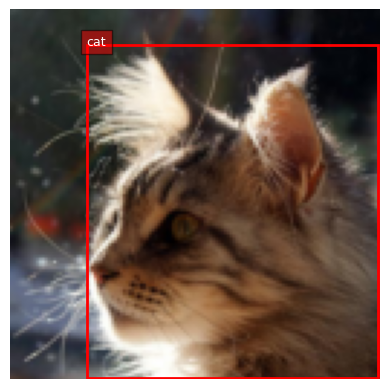

In [251]:
# Order of classes is available in the .yaml file
CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


idx = random.randint(0, len(train_dataset) - 1)
image, boxes = train_dataset[idx]

# tensor to numpy
image = image.permute(1, 2, 0).numpy()
h, w, _ = image.shape

plt.imshow(image)
ax = plt.gca()

for box in boxes:
    class_id, x, y, bw, bh = box.tolist()

    # convert YOLO → pixel coords
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    # draw box
    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        edgecolor='red',
        linewidth=2
    )
    ax.add_patch(rect)

    # label
    label = CLASS_NAMES[int(class_id)]
    ax.text(
        x1, y1,
        label,
        color='white',
        fontsize=9,
        bbox=dict(facecolor='red', alpha=0.5)
    )

plt.axis("off")
plt.show()

***
***

# 3 - Training the Model 

## 3 . 1 - Loss function

In [252]:
def yolo_loss(predictions, targets, num_classes, lambda_coord=10, lambda_noobj=0.5):
    """
    Computes YOLO loss.
    - predictions: Predicted tensor.
    - targets: Ground truth tensor.
    """
    # Unpack predictions and targets
    pred_boxes = predictions[..., :4]
    pred_conf = predictions[..., 4]
    pred_classes = predictions[..., 5:]
    target_boxes = targets[..., :4]
    target_conf = targets[..., 4]
    target_classes = targets[..., 5:]
    
    # Localization Loss
    box_loss = lambda_coord * torch.sum((pred_boxes - target_boxes) ** 2)

    # Confidence Loss
    obj_loss = torch.sum((pred_conf - target_conf) ** 2)
    noobj_loss = lambda_noobj * torch.sum((pred_conf[target_conf == 0]) ** 2)

    # Classification Loss
    class_loss = torch.sum((pred_classes - target_classes) ** 2)

    # Total Loss
    total_loss = box_loss + obj_loss + noobj_loss + class_loss
    return total_loss

## 3.2 - Helper function to match target format

This function encodes the ground-truth boxes into the format expected by the YOLO model:

- **S**: number of grid cells along one axis (S×S grid)  
- **B**: number of anchor boxes per grid cell  
- **C**: number of object classes  

It returns a tensor of shape `[S, S, B*5 + B*C]`, where each anchor in a cell stores:  
- 4 box coordinates `(x, y, w, h)`  
- 1 objectness score  
- C class probabilities (one-hot)  

In [253]:
def encode_target(boxes, S=32, B=3, C=20):
    """
    boxes: [num_boxes, 5] -> [class, x, y, w, h]
    returns: [S, S, B*5 + B*C] tensor
    """
    target = torch.zeros((S, S, B*5 + B*C))

    for box in boxes:
        class_label, x, y, w, h = box
        i = int(x * S)
        j = int(y * S)

        for b in range(B):
            target[j, i, b*5 : b*5+4] = torch.tensor([x, y, w, h])  # box coords
            target[j, i, b*5+4] = 1  # object confidence
            target[j, i, B*5 + b*C + int(class_label)] = 1  # class for this anchor

    return target

## 3 . 2 - Training Loop 

In [254]:
import torch.optim as optim

device = torch.device('cpu')

# Initialize model, optimizer, and loss function
model = YOLO(grid_size=8, num_classes=20, num_anchors=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = yolo_loss 

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = images.to(device)

        # encode targets (*)
        targets_batch = torch.stack([encode_target(t, S=16, B=3, C=20) for t in targets]).to(device)

        predictions = model(images)
        loss = yolo_loss(predictions, targets_batch, num_classes=20)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 540918.7485
Epoch 2/10, Loss: 39872.5359
Epoch 3/10, Loss: 19868.1749
Epoch 4/10, Loss: 15754.8105
Epoch 5/10, Loss: 14158.3874
Epoch 6/10, Loss: 13164.0938
Epoch 7/10, Loss: 12483.4624
Epoch 8/10, Loss: 12006.6616
Epoch 9/10, Loss: 11445.0972
Epoch 10/10, Loss: 11168.9821


***
***

# 4 - Evaluation of the Model 

## 4 . 1 - Loss on the training set 

In [256]:
model.eval()  # Set model to evaluation mode
total_loss = 0
num_batches = 0

with torch.no_grad():  # no gradients needed
    for images, targets in train_loader:
        images = images.to(device)
        # encode targets to match YOLO output shape
        targets_batch = torch.stack([encode_target(t, S=16, B=3, C=20) for t in targets]).to(device)

        predictions = model(images)
        loss = yolo_loss(predictions, targets_batch, num_classes=20)

        total_loss += loss.item()
        num_batches += 1

mean_loss = total_loss / num_batches
print(f"Mean YOLO loss on training set: {mean_loss:.4f}")

Mean YOLO loss on training set: 443.8399


## 4 . 2 - Visualize prediction 

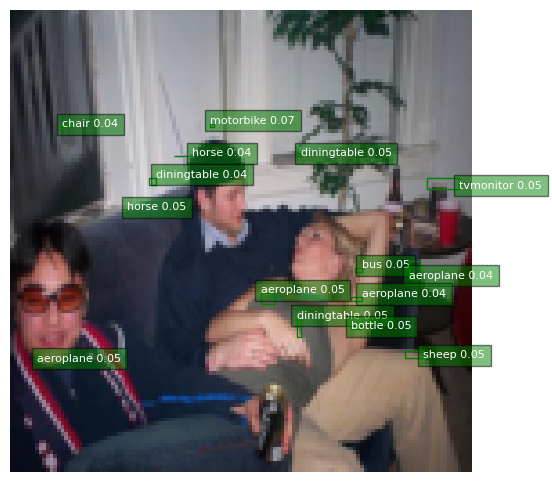

In [264]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Decode YOLO predictions into full-image normalized boxes ---
def decode_predictions(pred_tensor, S=8, B=3, C=20, conf_threshold=0.05):
    """
    Returns list of [class_id, conf, x_center, y_center, width, height]
    Only boxes with conf >= conf_threshold are returned
    All coordinates normalized to 0-1
    """
    boxes = []
    pred_tensor = pred_tensor.cpu().numpy()
    for i in range(S):
        for j in range(S):
            for b in range(B):
                offset = b*(5+C)
                x_cell, y_cell = pred_tensor[i,j,offset:offset+2]
                w, h = pred_tensor[i,j,offset+2:offset+4]
                conf = pred_tensor[i,j,offset+4]
                class_probs = pred_tensor[i,j,offset+5:offset+5+C]
                class_id = int(class_probs.argmax())
                
                if conf < conf_threshold:
                    continue
                
                # Convert to normalized full-image coordinates
                x = (j + x_cell)/S
                y = (i + y_cell)/S
                boxes.append([class_id, float(conf), float(x), float(y), float(w), float(h)])
    return boxes

# --- Visualize predictions ---
def visualize_predictions(image, boxes, class_labels):
    """
    Draw boxes on the image
    image: HWC numpy array in 0-1 range
    boxes: list of [class_id, conf, x, y, w, h] in normalized coordinates
    """
    h, w, _ = image.shape
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    ax = plt.gca()
    
    for box in boxes:
        class_id, conf, x, y, bw, bh = box
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        
        # Draw rectangle
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='green', linewidth=1)
        ax.add_patch(rect)
        
        # Label
        ax.text(
            x1, y1,
            f"{class_labels[class_id]} {conf:.2f}",
            color='white',
            fontsize=8,
            bbox=dict(facecolor='green', alpha=0.5)
        )
    
    plt.axis("off")
    plt.show()

# --- Pick a sample image ---
import random
idx = random.randint(0, len(train_dataset) - 1)
image_tensor, _ = train_dataset[idx]

# Convert tensor to numpy (HWC) for plotting
image = image_tensor.permute(1,2,0).numpy()

# --- Run model prediction ---
image_input = image_tensor.unsqueeze(0).to(device)  # add batch dim
model.eval()
with torch.no_grad():
    pred_tensor = model(image_input)[0]  # remove batch dim

# --- Decode predictions with low threshold to see rough guesses ---
boxes = decode_predictions(pred_tensor, S=16, B=3, C=20, conf_threshold=0.04)

# --- Visualize ---
visualize_predictions(image, boxes, CLASS_NAMES)

***
***

# 5 - Trying Data Augmentation

- Copy the training set 
- Add more details to it
- Evaluate the model again 

In [ ]:
import copy

aug_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((64, 64)),       
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor()
])

aug_train_dataset = copy.deepcopy(train_dataset)
aug_train_dataset.transforms = aug_transforms
aug_train_loader = torch.utils.data.DataLoader(
    aug_train_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn
)

model.eval()
total_loss = 0
num_batches = 0

with torch.no_grad():
    for images, targets in aug_train_loader:
        images = images.to(device)
        # **S matches model.grid_size**
        targets_batch = torch.stack([encode_target(t, S=8, B=3, C=20) for t in targets]).to(device)

        predictions = model(images)
        loss = yolo_loss(predictions, targets_batch, num_classes=20)

        total_loss += loss.item()
        num_batches += 1

mean_loss = total_loss / num_batches
print(f"Mean YOLO loss on augmented training set: {mean_loss:.4f}")

Mean YOLO loss on augmented training set: 182.5350
